# Classical Shadows → Hamiltonian Learning

**Author:** Jasper Sands · **Package:** `shadow_learning` v0.3.0

1. Pauli shadows of a Bell state and the unbiased estimator
2. Error versus snapshot budget
3. Derandomised shadows (Huang–Kueng–Preskill) beat random shadows
4. Readout errors: why asymmetric errors need single-shot inversion
5. Learning (J, h) from Gibbs-state shadows with JAX gradients — and identifiability
6. Streaming EKF tracking of a drifting coupling
7. Matchgate shadows and the fermionic 1-RDM
8. Shadow process tomography

Every number is computed by the package.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import cirq
from shadow_learning import (
    measure_random_pauli_shadows, sample_shadows_from_density_matrix, gibbs_state,
    estimate_many_observables, estimate_pauli_string_expectation, DerandomizedShadowSelector, hits_per_observable,
    ReadoutErrorModel, DifferentiableHamiltonianLearner, StreamingKalmanHamiltonianTracker,
    FermionicMatchgateShadows, slater_state, ShadowProcessTomographer, __version__,
)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})
print("shadow_learning", __version__, "| cirq", cirq.__version__)

shadow_learning 0.3.0 | cirq 1.7.0


## 1. Pauli shadows of a Bell state

Each snapshot measures every qubit in a uniformly random Pauli basis. For a weight-$k$ Pauli string the unbiased single-snapshot estimator is $\prod_i 3(-1)^{b_i}\delta(W_i,P_i)$.

In [2]:
q = cirq.LineQubit.range(2)
bell = cirq.Circuit(cirq.H(q[0]), cirq.CNOT(q[0], q[1]))
snaps = measure_random_pauli_shadows(bell, n_qubits=2, n_snapshots=3000, seed=1)
print("first snapshots:", snaps[:3])
print(estimate_many_observables(snaps, ["ZZ", "XX", "YY", "ZI"]), "   (truth 1, 1, −1, 0)")

first snapshots: [ShadowSnapshot(bases=(np.str_('Y'), np.str_('Y')), bits=(1, 0)), ShadowSnapshot(bases=(np.str_('X'), np.str_('X')), bits=(1, 1)), ShadowSnapshot(bases=(np.str_('X'), np.str_('X')), bits=(0, 0))]
{'ZZ': 0.984, 'XX': 0.948, 'YY': -1.014, 'ZI': -0.061}    (truth 1, 1, −1, 0)


## 2. Error versus snapshot budget

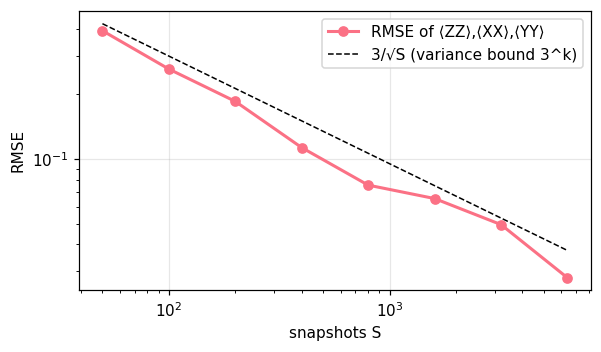

In [3]:
rho_bell = np.outer([1, 0, 0, 1], [1, 0, 0, 1]) / 2
budgets = [50, 100, 200, 400, 800, 1600, 3200, 6400]
errs = []
for S in budgets:
    trial = []
    for t in range(20):
        e = estimate_many_observables(sample_shadows_from_density_matrix(rho_bell, S, np.random.default_rng(1000 * S + t)), ["ZZ", "XX", "YY"])
        trial.append(np.sqrt(np.mean([(e["ZZ"] - 1) ** 2, (e["XX"] - 1) ** 2, (e["YY"] + 1) ** 2])))
    errs.append(np.mean(trial))
fig, ax = plt.subplots(figsize=(6, 3.3))
ax.loglog(budgets, errs, "o-", lw=2, color="#fb7185", label="RMSE of ⟨ZZ⟩,⟨XX⟩,⟨YY⟩")
ax.loglog(budgets, 3 / np.sqrt(budgets), "--", color="k", lw=1, label="3/√S (variance bound 3^k)")
ax.set_xlabel("snapshots S"); ax.set_ylabel("RMSE"); ax.legend(); plt.show()

## 3. Derandomised shadows

Algorithm 1 of Huang, Kueng & Preskill (2021) picks each shot's bases greedily to minimise the expected confidence bound $\sum_o e^{-\varepsilon^2 h_o/2}$. For a fixed observable set this beats random bases at equal budget.

In [4]:
learner3 = DifferentiableHamiltonianLearner(n_qubits=3, beta=1.0)
J3 = np.array([[0, 0.7, 0], [0.7, 0, -0.4], [0, -0.4, 0]]); h3 = np.array([0.2, 0.0, -0.3])
rho3 = gibbs_state(learner3.build_hamiltonian_matrix(J3, h3), 1.0)
targets = ["XXI", "YYI", "ZZI", "IXX", "IYY", "IZZ"]
truth = {P: float(np.real(np.trace(learner3.pauli_matrix(P) @ rho3))) for P in targets}
bases = DerandomizedShadowSelector(targets, n_qubits=3).select_measurement_bases(300)
print("first derandomised bases:", bases[:6])
print("coverage per target over 300 shots:", hits_per_observable(bases, targets))
rr, rd = [], []
for t in range(20):
    rng = np.random.default_rng(t)
    er = estimate_many_observables(sample_shadows_from_density_matrix(rho3, 300, rng), targets)
    ed = estimate_many_observables(sample_shadows_from_density_matrix(rho3, 300, rng, bases=bases), targets, derandomized=True)
    rr.append(np.sqrt(np.mean([(er[P] - truth[P]) ** 2 for P in targets]))); rd.append(np.sqrt(np.mean([(ed[P] - truth[P]) ** 2 for P in targets])))
print(f"RMSE random {np.mean(rr):.4f} | derandomised {np.mean(rd):.4f} | gain ×{np.mean(rr)/np.mean(rd):.2f}")

first derandomised bases: [('X', 'X', 'X'), ('Y', 'Y', 'Y'), ('Z', 'Z', 'Z'), ('X', 'X', 'X'), ('Y', 'Y', 'Y'), ('Z', 'Z', 'Z')]
coverage per target over 300 shots: {'XXI': 174, 'YYI': 63, 'ZZI': 63, 'IXX': 174, 'IYY': 63, 'IZZ': 63}
RMSE random 0.1638 | derandomised 0.0872 | gain ×1.88


## 4. Readout errors

With $p(1|0)=p_{01}$ and $p(0|1)=p_{10}$ the measured $\langle Z\rangle$ becomes $(1-p_{01}-p_{10})\langle Z\rangle + (p_{10}-p_{01})$: a scale *and* a shift. Dividing by $(1-p_{01}-p_{10})^k$ (v0.2) only fixes the scale. Replacing $(-1)^b$ by $g(b) = ((M^\top)^{-1}(1,-1))_b$ is exact.

In [5]:
plus = np.array([1, 1]) / np.sqrt(2); rho_p = np.outer(plus, plus)
model = ReadoutErrorModel(p01=0.02, p10=0.10)
snaps = sample_shadows_from_density_matrix(rho_p, 8000, np.random.default_rng(3), readout_error=model)
raw = estimate_pauli_string_expectation(snaps, "X")
print(f"raw <X> = {raw:.3f}   (prediction {(1-0.12)*1 + 0.08:.3f})")
print(f"symmetric rule <X>/(1-p01-p10) = {raw / model.readout_fidelity:.3f}   ← overshoots")
print(f"single-shot inversion            = {estimate_pauli_string_expectation(snaps, 'X', readout_model=model):.3f}   (truth 1)")
print("corrected eigenvalues g(0), g(1):", model.corrected_eigenvalue(0), model.corrected_eigenvalue(1))

raw <X> = 0.962   (prediction 0.960)
symmetric rule <X>/(1-p01-p10) = 1.093   ← overshoots
single-shot inversion            = 1.002   (truth 1)
corrected eigenvalues g(0), g(1): 1.0454545454545454 -1.227272727272727


## 5. Learning $(J, h)$ from Gibbs-state shadows

$H = \sum_{i<j} J_{ij}\,\vec\sigma_i\cdot\vec\sigma_j + \sum_i h_i Z_i$; the loss $\sum_o(\langle o\rangle_{\rho_\beta(J,h)} - \hat o)^2$ is minimised with JAX gradients through the eigendecomposition. The Jacobian's singular values tell which parameter combinations the data can resolve.

β = 0.6: J01 +0.509 (0.500)   h [ 0.366 -0.282] ([ 0.4  -0.25])   jax-lbfgs, 11 it, 0.34 s
        singular values [1.345 0.696 0.362]  condition 3.7  least identifiable direction (J01, h0, h1) = [-0.03 -0.72 -0.69]
β = 1.5: J01 +0.495 (0.500)   h [ 0.354 -0.295] ([ 0.4  -0.25])   jax-lbfgs, 33 it, 0.12 s
        singular values [1.792 0.929 0.2  ]  condition 9.0  least identifiable direction (J01, h0, h1) = [0.07 0.75 0.66]
At β = 1.5 the state is ~singlet, which screens a uniform field: h0 + h1 is poorly determined while h0 − h1 and J are fine.


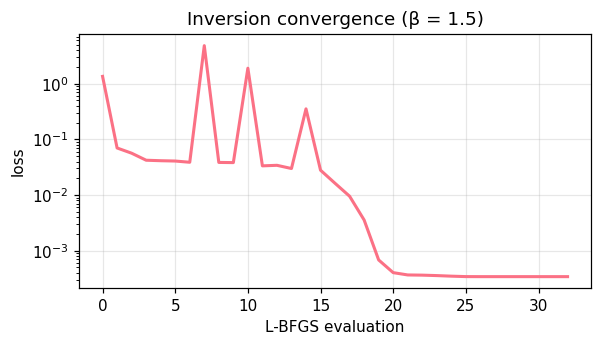

In [6]:
for beta in (0.6, 1.5):
    learner = DifferentiableHamiltonianLearner(n_qubits=2, beta=beta, seed=1)
    J = np.array([[0, 0.5], [0.5, 0]]); h = np.array([0.4, -0.25])
    rho = gibbs_state(learner.build_hamiltonian_matrix(J, h), beta)
    snaps = sample_shadows_from_density_matrix(rho, 8000, np.random.default_rng(5))
    t0 = time.time(); res = learner.learn_from_shadows(snaps, true_j_matrix=J, true_h_vector=h); dt = time.time() - t0
    ident = learner.identifiability(J, h)
    print(f"β = {beta}: J01 {res.recovered_j_matrix[0,1]:+.3f} (0.500)   h {np.round(res.recovered_h_vector, 3)} ({h})   "
          f"{res.method}, {res.iterations} it, {dt:.2f} s")
    print(f"        singular values {np.round(ident['singular_values'], 3)}  condition {ident['condition_number']:.1f}  "
          f"least identifiable direction (J01, h0, h1) = {np.round(ident['least_identifiable'], 2)}")
print("At β = 1.5 the state is ~singlet, which screens a uniform field: h0 + h1 is poorly determined while h0 − h1 and J are fine.")
fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogy(res.loss_history, lw=2, color="#fb7185"); ax.set_xlabel("L-BFGS evaluation"); ax.set_ylabel("loss"); ax.set_title("Inversion convergence (β = 1.5)"); plt.show()

## 6. Streaming EKF

Each snapshot updates the estimate of $(J, h)$ through the linearised Gibbs observable model; a step change in $J_{01}$ is tracked without re-fitting.

estimate at 1400: 0.346  at 3000: 0.812


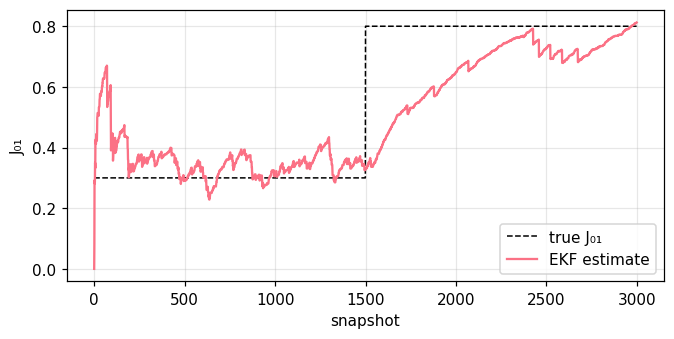

In [7]:
tracker = StreamingKalmanHamiltonianTracker(n_qubits=2, beta=1.5, process_noise_std=0.005, seed=0)
rng = np.random.default_rng(7); est, truth_j = [], []
for k in range(3000):
    jv = 0.3 if k < 1500 else 0.8
    if k % 250 == 0:
        rho_k = gibbs_state(tracker.learner.build_hamiltonian_matrix(np.array([[0, jv], [jv, 0]]), np.array([0.2, -0.15])), 1.5)
    tracker.process_snapshot(sample_shadows_from_density_matrix(rho_k, 1, rng)[0])
    est.append(tracker.x[0]); truth_j.append(jv)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(truth_j, color="k", lw=1, ls="--", label="true J₀₁"); ax.plot(est, color="#fb7185", lw=1.5, label="EKF estimate")
ax.set_xlabel("snapshot"); ax.set_ylabel("J₀₁"); ax.legend(); plt.show()
print(f"estimate at 1400: {est[1399]:.3f}  at 3000: {est[-1]:.3f}")

## 7. Matchgate shadows

Random signed-permutation Clifford matchgates pair up Majoranas; each snapshot measures $n$ commuting pair operators. The 1-RDM $D_{pq} = \langle c_p^\dagger c_q\rangle$ follows from the estimated Majorana two-point function.

In [8]:
fs = FermionicMatchgateShadows(n_modes=4, seed=2)
psi = (slater_state(4, [1, 3]) + slater_state(4, [0, 3])) / np.sqrt(2)     # one delocalised orbital + one localised
t0 = time.time(); snaps = fs.sample(psi, n_snapshots=6000); D = fs.estimate_1rdm(snaps); dt = time.time() - t0
print("estimated 1-RDM (real part):"); print(np.round(D.real, 2))
print("exact:"); print(np.round(fs.exact_1rdm(psi).real, 2))
print(f"max |error| = {np.abs(D - fs.exact_1rdm(psi)).max():.3f}   ({dt:.1f} s)")

estimated 1-RDM (real part):
[[ 0.48  0.49 -0.   -0.01]
 [ 0.49  0.5  -0.02  0.01]
 [-0.   -0.02 -0.02 -0.  ]
 [-0.01  0.01 -0.    0.98]]
exact:
[[0.5 0.5 0.  0. ]
 [0.5 0.5 0.  0. ]
 [0.  0.  0.  0. ]
 [0.  0.  0.  1. ]]
max |error| = 0.020   (0.5 s)


## 8. Shadow process tomography

In [9]:
tomo = ShadowProcessTomographer(n_qubits=1, seed=0)
p = 0.25
dep = lambda r: (1 - p) * r + p * np.trace(r) * np.eye(2) / 2
res = tomo.run(dep, n_snapshots_per_input=2000)
print("PTM of a depolarising channel (p = 0.25):"); print(np.round(res["ptm"], 2))
print(f"average gate fidelity vs identity: {tomo.average_gate_fidelity(res['ptm'], np.eye(2)):.3f}   (exact {(2*(1-0.75*p)+1)/3:.3f})")
print(f"Tr(Choi) = {np.trace(res['choi']).real:.3f} (2 for trace preservation)")

PTM of a depolarising channel (p = 0.25):
[[ 1.    0.    0.    0.  ]
 [ 0.01  0.73  0.02  0.01]
 [ 0.02  0.02  0.77 -0.01]
 [-0.01  0.01  0.03  0.76]]
average gate fidelity vs identity: 0.877   (exact 0.875)
Tr(Choi) = 2.000 (2 for trace preservation)
